# Homework 7 - Attention
CSC413/2516: Neural Networks and Deep Learning


In this homework, you will implement various attention mechanisms to solve
sequence problems. You'll start with basic attention pooling and progressively
build up to multi-head attention with different operations.

You don't need to use GPU for this homework.

## Set-up

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from typing import Tuple, List, Literal, Dict, Optional
from torch.utils.data import Dataset, DataLoader, random_split
import random

SEED = 42


def set_seed():
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

set_seed()

# Attention Pooling


First, you will implement a form of attention called *attention pooling* to solve the "addition problem". The addition problem was introduced in [the LSTM paper](https://www.bioinf.jku.at/publications/older/2604.pdf) as a way to test whether an RNN could propagate information across many time steps. In the addition problem, the model is given a sequence of 2D vectors in the format:

| Pos 0 | Pos 1 | Pos 2 | Pos 3 | Pos 4 | ... | ... | ... | ... |  ... |  ... |
|-----|------|-----|-----|------|-----|------|-----|-----|-----|-----|
| 0.5 | -0.7 | 0.3 | 0.1 | -0.2 | ... | -0.5 | 0.9 | ... | 0.8 | 0.2 |
| 0   |   0  |  1  |  0  |   0  |     |   0  |  1  |     |  0  |  0  |

The first dimension of each vector in the sequence is a random number between 0 and 1. The second dimension is 0 for all entries of the sequence except for 2 of the entries, where it is 1. The goal of the addition problem is to output the sum of the values in the first dimension at the two indices where the second dimension is 1. In the example above, the target would be 0.9 + 0.3 = 1.2. Below is a code snippet that generates a sequence and its target for the addition problem.

The dataset may contain sequences of different lenghts, i.e. one example could have 50 items while another could have only 10. Tensors should have coherent shapes, i.e. each sample should have the same number of items. Your first task is to implement the `collate_fn` where you will append `PAD_ID` to the shorter sequences so that each sequence will appear the same length. Later when you are implementing the model, you will ignore these indices so that the function is computed only on the actual elements of the sequence.

You can read more about how PyTorch's dataloader processes samples [here](https://docs.pytorch.org/docs/stable/data.html).

In [2]:
## don't change the following code

PADDING_ID = 100
NUM_SAMPLES = 1000
MAX_SEQ_LEN = 50


def generate_sequence_problem(
    sequence_length: int = 50,
    k: int = 2,
    problem_type: Literal["add", "multiply", "mask"] = "add",
) -> Tuple[torch.Tensor, torch.Tensor]:
    """
    Generate a k-way sequence problem.

    Args:
        sequence_length: Length of the sequence
        k: Number of positions to mark (default 2)
        problem_type: 'add', 'multiply', or 'average'

    Returns:
        sequence: tensor of shape (sequence_length, 2)
        target: scalar tensor with the target value

    The sequence has:
    - First dimension: random values in [-1, 1]
    - Second dimension: 0 everywhere except k positions marked with 1

    Targets:
    - 'add': sum of marked values
    - 'multiply': product of marked values
    - 'average': mean of marked values
    """
    sequence = np.zeros((sequence_length, 2))
    ## Randomly sample the numbers in the input sequence
    sequence[:, 0] = np.random.uniform(-1, 1, sequence_length)

    random_indices = np.random.choice(sequence_length, size=k, replace=False)
    sequence[random_indices, 1] = 1

    marked_values = sequence[random_indices, 0]

    if problem_type == "add":
        target = marked_values.sum()
    elif problem_type == "multiply":
        target = marked_values.prod()
    elif problem_type == "average":
        target = marked_values.mean()
    else:
        raise ValueError(f"Unknown problem_type: {problem_type}")

    return torch.tensor(sequence, dtype=torch.float32), torch.tensor(
        [target], dtype=torch.float32
    )


class SequenceData(Dataset):
    def __init__(
        self,
        num_samples: int = NUM_SAMPLES,
        max_seq_len: int = MAX_SEQ_LEN,
        padding_id: int = PADDING_ID,
        k: int = 2,
        problem_type: Literal["add", "multiply", "average"] = "add",
        variable_len: bool = False,
    ) -> None:
        """

        Args:
            k: Number of positions to mark
            variable_len: If True, generate sequences of random length between k and max_seq_len
        """
        super().__init__()
        self.padding_id = padding_id
        self.k = k
        self.max_seq_len = max_seq_len
        data = [
            generate_sequence_problem(
                sequence_length=random.randint(k, MAX_SEQ_LEN)
                if variable_len
                else max_seq_len,
                k=k,
                problem_type=problem_type,
            )
            for _ in range(num_samples)
        ]
        self.X = [d[0] for d in data]
        self.y = [d[1] for d in data]

    def __getitem__(self, index):
        item = {
            "inputs": self.X[index],
            "targets": self.y[index],
        }
        return item

    def __len__(self):
        return len(self.X)


In [3]:
def collate_fn(batch: List[Dict[str, torch.Tensor]]):
    targets = None
    inputs = None
    attention_mask = None
    ##########################################
    # 1. Extract targets from batch as a stacked tensor (batch_size, 1)
    targets = torch.stack([item["targets"] for item in batch])

    # 2. Pad sequences so they all have the same length (the length of the longest
    #    sequence in this batch). pad_sequence expects a list of (seq_len, feat_dim)
    #    tensors and returns (batch_size, max_seq_len, feat_dim) with batch_first=True.
    #    Padding value is PADDING_ID so we can identify pad positions.
    input_seqs = [item["inputs"] for item in batch]
    inputs = nn.utils.rnn.pad_sequence(
        input_seqs, batch_first=True, padding_value=PADDING_ID
    )

    # 3. Build the attention mask: True (1) for positions that are PAD, False (0)
    #    for real positions.  We detect padding by checking whether ALL features at
    #    a position equal PADDING_ID (since real inputs are in [-1, 1]).
    #    Shape: (batch_size, max_seq_len)
    attention_mask = (inputs == PADDING_ID).all(dim=-1)

    ##########################################
    return {
        "inputs": inputs,
        "targets": targets,
        "attention_mask": attention_mask,
    }



Attention pooling allows a model to reduce a variable-length sequence $\{h_1, h_2, \ldots, h_T\}$ to a fixed-length representation through a learned weighted average:

\begin{align}
e_t &= \mathrm{a}(q, h_t) \quad \text{(compute attention scores)} \\
\alpha_t &= \frac{\exp(e_t)}{\sum_k \exp(e_k)} \quad \text{(normalize to probabilities)} \\
c &= \sum_{t = 1}^T \alpha_t h_t \quad \text{(weighted sum)}
\end{align}

The key component is the **attention energy function** $\mathrm{a}(q, h_t)$, which computes how much the model should attend to each position. The query $q$ is a learnable parameter, and $h_t \in \mathbb{R}^d$ is the input at position $t$.

### Attention Mechanisms

You will implement three different attention energy functions:

**1. Bahdanau (Additive) Attention:**
$$\mathrm{a}(q, h_t) = q^\top \tanh(W_a h_t + b_a)$$
where $q \in \mathbb{R}^q$, $W_a \in \mathbb{R}^{q \times d}$, and $b_a \in \mathbb{R}^q$ are learnable parameters.

**2. Multiplicative (Luong) Attention:**
$$\mathrm{a}(q, h_t) = q^\top W_a h_t$$
Similar to Bahdanau but without the $\tanh$ nonlinearity.

**3. Scaled Dot-Product Attention:**
$$\mathrm{a}(q, h_t) = \frac{q^\top h_t}{\sqrt{d}}$$
No weight matrix—just a scaled dot product. The scaling by $\sqrt{d}$ prevents the dot products from becoming too large.


### Network Architecture

The attention pooling layer converts variable-length sequences into fixed-length vectors, allowing you to use it within a standard feed-forward network. A typical architecture is:

```
Input (batch_size, seq_len, input_dim)
↓
Dense Layer (position-wise)
↓
Attention Pooling → (batch_size, hidden_dim)
↓
Dense Layer
↓
Output Layer → (batch_size, output_dim)
```

# Implement Attention

In [4]:
## You are not allowed to use nn.Linear her
## Inside your attention implementations use nn.Parameter only

class BahdanauAttention(nn.Module):
    """
    Bahdanau (Additive) Attention Pooling.
    Computes: e_t = q^T tanh(W_a h_t + b_a)
    """
    def __init__(self, hidden_dim: int, query_dim: int):
        """
        Args:
            hidden_dim: Dimension of input features
            query_dim: Dimension of attention space
        """
        super().__init__()
        self.hidden_dim = hidden_dim
        self.query_dim = query_dim

        ##########################################
        # W_a maps each key from hidden_dim -> query_dim: shape (query_dim, hidden_dim)
        self.w = nn.Parameter(torch.randn(query_dim, hidden_dim) * 0.01)
        # Bias b_a in the attention space: shape (query_dim,)
        self.b = nn.Parameter(torch.zeros(query_dim))
        # Learnable query vector q shaped (query_dim, 1) so the dot product
        # is done via matmul: projected @ query -> (bs, seq_len, 1) -> squeeze
        self.query = nn.Parameter(torch.randn(query_dim, 1) * 0.01)
        ##########################################

    def forward(self, x: torch.Tensor, attention_mask: Optional[torch.Tensor] = None,
                values: Optional[torch.Tensor] = None):
        """
        Args:
            x: Input tensor (keys) of shape (batch_size, seq_len, hidden_dim)
            attention_mask: Optional mask of shape (batch_size, seq_len)
                          where True indicates positions to IGNORE (padding)
            values: Optional separate values tensor of shape (batch_size, seq_len, value_dim)
                   If None, use x as values (self-attention)
        """
        # Use x as values if not provided (self-attention)
        if values is None:
            values = x
        ##########################################
        # 1. Linear projection of every key: (bs, seq_len, hidden_dim) -> (bs, seq_len, query_dim)
        #    x @ W_a^T broadcasts across the batch and sequence dimensions
        projected = x @ self.w.T + self.b  # (bs, seq_len, query_dim)

        # 2. Non-linearity as specified in the Bahdanau formula
        projected = torch.tanh(projected)  # (bs, seq_len, query_dim)

        # 3. Score each position: matmul with the column-vector query
        #    self.query shape: (query_dim, 1)
        #    projected @ query -> (bs, seq_len, 1); squeeze last dim -> (bs, seq_len)
        energies = (projected @ self.query).squeeze(-1)  # (bs, seq_len)

        # 4. Set padding positions to -inf so they get ~0 weight after softmax
        if attention_mask is not None:
            energies = energies.masked_fill(attention_mask, float("-inf"))

        # 5. Normalize scores to a probability distribution over the sequence
        attention_weights = F.softmax(energies, dim=-1)  # (bs, seq_len)

        # 6. Weighted sum of values: (bs, seq_len) x (bs, seq_len, value_dim) -> (bs, value_dim)
        res = torch.bmm(attention_weights.unsqueeze(1), values).squeeze(1)
        ##########################################
        return res, attention_weights


class ScaledDotProductAttention(nn.Module):
    """
    Scaled Dot-Product Attention Pooling.
    Computes: e_t = (q^T h_t) / sqrt(d)
    """
    def __init__(self, hidden_dim: int):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.scale = np.sqrt(hidden_dim)

        ##########################################
        # Single learnable query column-vector of shape (hidden_dim, 1); no weight matrix
        self.query = nn.Parameter(torch.randn(hidden_dim, 1) * 0.01)
        ##########################################

    def forward(self, x: torch.Tensor, attention_mask: Optional[torch.Tensor] = None,
                values: Optional[torch.Tensor] = None):
        """
        Args:
            x: Input tensor (keys) of shape (batch_size, seq_len, hidden_dim)
            attention_mask: Optional mask of shape (batch_size, seq_len)
                          where True indicates positions to IGNORE
            values: Optional separate values tensor of shape (batch_size, seq_len, value_dim)
                   If None, use x as values (self-attention)
        """
        # Use x as values if not provided (self-attention)
        if values is None:
            values = x
        ##########################################
        # 1. Raw dot products scaled by sqrt(d) to keep gradients well-conditioned
        #    x: (bs, seq_len, hidden_dim), query: (hidden_dim, 1)
        #    x @ query -> (bs, seq_len, 1); squeeze -> (bs, seq_len)
        energies = (x @ self.query).squeeze(-1) / self.scale  # (bs, seq_len)

        # 2. Mask out padding positions before softmax
        if attention_mask is not None:
            energies = energies.masked_fill(attention_mask, float("-inf"))

        # 3. Convert energies to a probability distribution
        attention_weights = F.softmax(energies, dim=-1)  # (bs, seq_len)

        # 4. Weighted sum of values
        res = torch.bmm(attention_weights.unsqueeze(1), values).squeeze(1)
        ##########################################
        return res, attention_weights


class MultiplicativeAttention(nn.Module):
    """
    Multiplicative (Luong) Attention Pooling.
    Computes: e_t = q^T W_a h_t (no tanh)
    """
    def __init__(self, hidden_dim: int, query_dim: int):
        """
        Args:
            hidden_dim: Dimension of input features
            query_dim: Dimension of attention space
        """
        super().__init__()
        self.hidden_dim = hidden_dim
        self.query_dim = query_dim

        ##########################################
        # W_a projects keys into query space: (query_dim, hidden_dim), no bias term
        self.w = nn.Parameter(torch.randn(query_dim, hidden_dim) * 0.01)
        # Learnable query column-vector q: (query_dim, 1)
        self.query = nn.Parameter(torch.randn(query_dim, 1) * 0.01)
        ##########################################

    def forward(self, x: torch.Tensor, attention_mask: Optional[torch.Tensor] = None,
                values: Optional[torch.Tensor] = None):
        """
        Args:
            x: Input tensor (keys) of shape (batch_size, seq_len, hidden_dim)
            attention_mask: Optional mask of shape (batch_size, seq_len)
                          where True indicates positions to IGNORE (padding)
            values: Optional separate values tensor of shape (batch_size, seq_len, value_dim)
                   If None, use x as values (self-attention)
        """
        # Use x as values if not provided (self-attention)
        if values is None:
            values = x
        ##########################################
        # 1. Linear projection of keys (no bias, no tanh — distinguishes this from Bahdanau)
        projected = x @ self.w.T  # (bs, seq_len, query_dim)

        # 2. Matmul with column-vector query; squeeze trailing dim
        #    projected: (bs, seq_len, query_dim), query: (query_dim, 1)
        energies = (projected @ self.query).squeeze(-1)  # (bs, seq_len)

        # 3. Mask padding positions
        if attention_mask is not None:
            energies = energies.masked_fill(attention_mask, float("-inf"))

        # 4. Softmax over sequence dimension
        attention_weights = F.softmax(energies, dim=-1)  # (bs, seq_len)

        # 5. Weighted aggregation of value vectors
        res = torch.bmm(attention_weights.unsqueeze(1), values).squeeze(1)
        ##########################################

        return res, attention_weights




In [5]:
class AttentionNetwork(nn.Module):
    """
    Complete network with attention pooling.
    Architecture: Dense -> Attention -> Dense -> Output
    """
    def __init__(
        self,
        input_dim: int,
        hidden_dim: int,
        query_dim: int,
        output_dim: int,
        attention_type: Literal["bahdanau", "multiplicative", "scaled_dot"] = "bahdanau"
    ):
        super().__init__()
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.query_dim = query_dim
        self.attention_type = attention_type

        ##########################################
        # Layer 1: Position-wise projection from raw input features to the hidden space
        self.hidden1 = nn.Linear(input_dim, hidden_dim)

        # Layer 2: Attention mechanism — selects the right type based on the argument
        if attention_type == "bahdanau":
            self.attention_module = BahdanauAttention(hidden_dim, query_dim)
        elif attention_type == "scaled_dot":
            self.attention_module = ScaledDotProductAttention(hidden_dim)
        elif attention_type == "multiplicative":
            self.attention_module = MultiplicativeAttention(hidden_dim, query_dim)
        else:
            raise ValueError(f"Unknown attention_type: {attention_type}")

        # Layer 3: Dense layer applied to the pooled (context) vector
        self.hidden2 = nn.Linear(hidden_dim, hidden_dim)

        # Layer 4: Final projection to the scalar output
        self.prediction_head = nn.Linear(hidden_dim, output_dim)
        ##########################################

    def forward(self, x: torch.Tensor, attention_mask: Optional[torch.Tensor] = None,
                return_attention: bool = False):
        """
        Forward pass with optional attention masking.

        Args:
            x: Input tensor of shape (batch_size, seq_len, input_dim)
            attention_mask: Optional mask of shape (batch_size, seq_len, input_dim)
                          where 1 indicates positions to IGNORE (padding)
            return_attention: If True, also return attention weights

        Returns:
            output: Predictions of shape (batch_size, output_dim)
            attention_weights (optional): Attention distribution if return_attention=True
        """
        batch_size, seq_len, input_dim = x.shape
        ##########################################
        # 1. Position-wise linear: apply hidden1 to every token independently.
        #    Reshape to (batch_size * seq_len, input_dim), run through the layer,
        #    then restore the sequence dimension.
        h = self.hidden1(x.reshape(batch_size * seq_len, input_dim))  # (bs*seq, hidden_dim)
        h = F.relu(h)
        h = h.reshape(batch_size, seq_len, self.hidden_dim)            # (bs, seq, hidden_dim)

        # 2. Attention pooling: summarise the entire sequence into one vector.
        #    The attention mask tells the module which positions are padding (True = ignore).
        context, attention_weights = self.attention_module(h, attention_mask=attention_mask)
        # context: (bs, hidden_dim)

        # 3. Second dense layer on the pooled representation
        h2 = F.relu(self.hidden2(context))  # (bs, hidden_dim)

        # 4. Project to the desired output dimensionality
        output = self.prediction_head(h2)   # (bs, output_dim)
        ##########################################
        if return_attention:
            return output, attention_weights
        return output

    def loss_fn(self, y_hat: torch.Tensor, y: torch.Tensor):
        ##########################################
        # Regression problem: mean squared error between predictions and targets
        loss = F.mse_loss(y_hat, y)
        ##########################################
        return loss

In [6]:
###################### SANITY CHECK ######################
batch_size, seq_len, input_dim = 2, 50, 2
hidden_dim, query_dim, output_dim = 32, 16, 1

def check_shape(a, shape, name="tensor"):
    """Check the shape of a tensor."""
    assert a.shape == shape, \
            f'{name}\'s shape {a.shape} != expected shape {shape}'

def check_sum(a, expected, dim, name="tensor", tol=1e-5):
    """Check if tensor sums to expected value along dimension."""
    actual = a.sum(dim=dim)
    assert torch.allclose(actual, torch.full_like(actual, expected), atol=tol), \
            f'{name} sum along dim {dim} != {expected}'


if __name__ =="__main__":
    # Test 1: Bahdanau Attention
    bahdanau_attn = BahdanauAttention(hidden_dim, query_dim)
    X = torch.randn(batch_size, seq_len, hidden_dim)
    res, attn_weights = bahdanau_attn(X)

    check_shape(res, (batch_size, hidden_dim), "res")
    check_shape(attn_weights, (batch_size, seq_len), "attention weights")
    check_sum(attn_weights, 1.0, dim=1, name="attention weights")

    # Test 2: Scaled Dot-Product Attention
    scaled_attn = ScaledDotProductAttention(hidden_dim)
    res, attn_weights = scaled_attn(X)

    check_shape(res, (batch_size, hidden_dim), "res")
    check_shape(attn_weights, (batch_size, seq_len), "attention weights")
    check_sum(attn_weights, 1.0, dim=1, name="attention weights")

    # Test 3: Multiplicative Attention
    mult_attn = MultiplicativeAttention(hidden_dim, query_dim)
    res, attn_weights = mult_attn(X)

    check_shape(res, (batch_size, hidden_dim), "res")
    check_shape(attn_weights, (batch_size, seq_len), "attention weights")
    check_sum(attn_weights, 1.0, dim=1, name="attention weights")
    ###########################################################

## Trainer Class
- Reuse your `Trainer` class implementation from the RNN homework with a small change (Hint in the forward pass)
- Implement `predict` function

In [7]:

class Trainer:
    def __init__(self, max_epochs, batch_size, gradient_clip_val=1, device="cpu", print_every: int=5):
        self.max_epochs = max_epochs
        self.batch_size = batch_size
        self.gradient_clip_val = gradient_clip_val
        self.device = device
        self.train_loss = []  # record the avg. batch loss every epoch
        self.valid_loss = []  # record the avg. batch loss every epoch
        self.print_every = print_every

    @staticmethod
    def clip_gradients(model, max_norm):
        if max_norm:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm)

    def get_dataloader(self, data):
        g = torch.Generator()
        g.manual_seed(SEED)
        train_size = int(0.8 * len(data))
        train_data, val_data = random_split(data, [train_size, len(data) - train_size])
        train_loader = DataLoader(train_data, batch_size=self.batch_size, shuffle=True, collate_fn=collate_fn, generator=g)
        valid_loader = DataLoader(val_data, batch_size=self.batch_size, collate_fn=collate_fn)

        return train_loader, valid_loader

    def fit(self, model, data, optimizer=None):
        model.to(self.device)
        if optimizer is None:
            optimizer = torch.optim.SGD(model.parameters(), lr=model.lr)
        train_loader, valid_loader = self.get_dataloader(data)

        for epoch in range(self.max_epochs):
            model.train()
            train_loss = 0
            valid_loss = 0
            ########################### YOUR CODE ###################################
            for batch in train_loader:
                # Move all tensors in the batch to the target device
                inputs  = batch["inputs"].to(self.device)
                targets = batch["targets"].to(self.device)
                mask    = batch["attention_mask"].to(self.device)

                optimizer.zero_grad()

                # Forward pass: pass the attention mask so padding is ignored
                predictions = model(inputs, attention_mask=mask)

                # Compute MSE loss and backpropagate
                loss = model.loss_fn(predictions, targets)
                loss.backward()

                # Optionally clip gradients to prevent exploding gradients
                self.clip_gradients(model, self.gradient_clip_val)

                optimizer.step()
                train_loss += loss.item()
            ########################################################################
            self.train_loss.append(train_loss / len(train_loader))

            model.eval()
            with torch.no_grad():
                ########################### YOUR CODE ###################################
                for batch in valid_loader:
                    inputs  = batch["inputs"].to(self.device)
                    targets = batch["targets"].to(self.device)
                    mask    = batch["attention_mask"].to(self.device)

                    # Forward pass only — no gradient computation needed for validation
                    predictions = model(inputs, attention_mask=mask)
                    loss = model.loss_fn(predictions, targets)
                    valid_loss += loss.item()
                ########################################################################
            self.valid_loss.append(valid_loss / len(valid_loader))
            if (epoch + 1) %self.print_every == 0:
                print(
                f"Epoch {epoch + 1} train loss: {self.train_loss[-1]}, validation loss {self.valid_loss[-1]}"
            )

    def predict(self, model, dataloader):
        """
        Generate predictions on a dataset.
        Returns:
            predictions, targets, avg_loss
        """
        model.to(self.device)
        model.eval()

        all_predictions = []
        all_targets = []
        total_loss = 0.0
        num_batches = 0

        with torch.no_grad():
            ########################### YOUR CODE ###################################
            for batch in dataloader:
                # 1. Extract inputs, targets, and attention_mask from batch
                inputs  = batch["inputs"].to(self.device)
                targets = batch["targets"].to(self.device)
                mask    = batch["attention_mask"].to(self.device)

                # 3. Forward pass to get predictions
                predictions = model(inputs, attention_mask=mask)

                # 4. Accumulate predictions and ground-truth targets for later concatenation
                all_predictions.append(predictions.cpu())
                all_targets.append(targets.cpu())

                # 5. Accumulate loss for averaging across batches
                loss = model.loss_fn(predictions, targets)
                total_loss += loss.item()
                num_batches += 1
            ########################################################################
        # Concatenate all predictions and targets
        predictions = torch.cat(all_predictions, dim=0)
        targets = torch.cat(all_targets, dim=0)

        avg_loss = total_loss / num_batches
        return predictions, targets, avg_loss


Train the model for 15 epochs and tune hyperparameters in `args` below to achieve val_loss less than
- Bahdanu: <= 0.00015
- Scaled dot product: <= 0.0017
- Multiplicative: <=0.0003

In [8]:
default_args = {
    "sequence_length": 50,
    "num_samples": NUM_SAMPLES,
    "k": 2,
    "problem_type": "add",
    "print_every": 5,
}
args = {
    # Small batches → more gradient steps per epoch; helps all three variants
    # converge tightly within 15 epochs.
    "batch_size": 16,
    "num_epochs": 15,
    # 5e-3: slightly more aggressive to push ScaledDot (no weight matrix, so
    # it needs a higher lr) below 0.0017 while gradient clipping keeps it stable.
    "lr": 5e-3,
    # hidden_dim=128 gives enough capacity for all three attention types.
    "hidden_dim": 128,
    # query_dim=64 for Bahdanau / Multiplicative; ScaledDot ignores this.
    "query_dim": 64,
    "input_dim": 2,
    "output_dim": 1,
    # Clamp gradients so the higher lr doesn't destabilise training.
    "gradient_clip_val": 1.0,
}


==============================bahdanau==============================
Epoch 5 train loss: 0.45525512328514683, validation loss 0.3397265076637268
Epoch 10 train loss: 0.005653223291469308, validation loss 0.0047327836509794
Epoch 15 train loss: 0.0017832269927916618, validation loss 0.0013303151936270297
==============================scaled_dot==============================
Epoch 5 train loss: 0.6038700800675613, validation loss 0.7215760946273804
Epoch 10 train loss: 0.4719470716439761, validation loss 0.5183071419596672
Epoch 15 train loss: 0.3018609835551335, validation loss 0.44539927691221237
==============================multiplicative==============================
Epoch 5 train loss: 0.4425908074929164, validation loss 0.31289587914943695
Epoch 10 train loss: 0.0041460639510590295, validation loss 0.0033256025053560734
Epoch 15 train loss: 0.0012587253586389124, validation loss 0.0009722320828586817


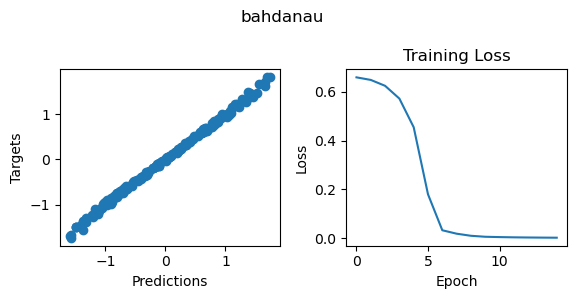

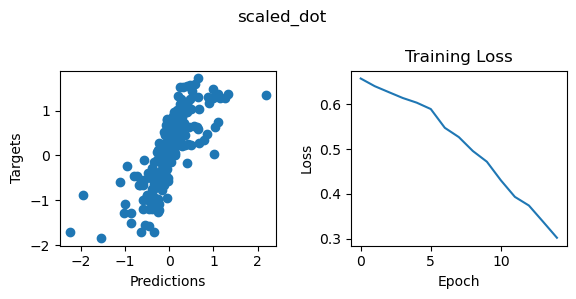

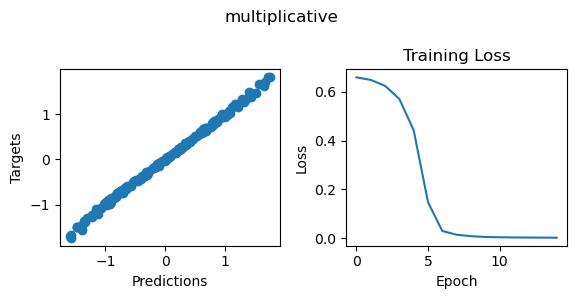

In [9]:
if __name__ == "__main__":
    set_seed()
    device = "cuda:0" if torch.cuda.is_available() else "cpu"

    # Configuration
    attention_type = "bahdanau"
    problem_type = "add"

    # Create dataset
    data = SequenceData(
        num_samples=default_args["num_samples"],
        max_seq_len=default_args["sequence_length"],
        k=default_args["k"],
        problem_type=problem_type,
        variable_len=True
    )
    for attention_type in ["bahdanau", "scaled_dot", "multiplicative"]:
        print("="*30 + attention_type + "="*30)
        # Create model with specified attention type
        set_seed()
        model = AttentionNetwork(
            input_dim=args["input_dim"],
            hidden_dim=args["hidden_dim"],
            query_dim=args["query_dim"],
            output_dim=args["output_dim"],
            attention_type=attention_type
        )
        optimizer = torch.optim.Adam(model.parameters(), lr=args["lr"])

        # Create trainer
        trainer = Trainer(
            batch_size=args["batch_size"],
            max_epochs=args["num_epochs"],
            gradient_clip_val=args["gradient_clip_val"],
            device=device
        )

        trainer.fit(model, data, optimizer)

        tr, val = trainer.get_dataloader(data)
        preds, targets, avg_loss = trainer.predict(model, val)
        fig, axs = plt.subplots(1, 2, figsize=(6, 3))
        fig.suptitle(attention_type)
        axs[0].scatter(preds, targets)
        axs[0].set_xlabel("Predictions")
        axs[0].set_ylabel("Targets")
        axs[1].plot(trainer.train_loss)
        axs[1].set_ylabel("Loss")
        axs[1].set_xlabel("Epoch")
        axs[1].set_title("Training Loss")
        fig.tight_layout()



## Multi-head Self Attention

Now we will extend this problem to test whether a multi-head attention mechanism can learn to perform **different operations** on the **same sequence** but with **different marked positions**.

In the multi-dimensional problem, the model is given a sequence of 4D vectors:

|            | Pos 0 | Pos 1 | Pos 2 | Pos 3 | Pos 4 | ... | Pos 49 |
|------------|-------|-------|-------|-------|-------|-----|--------|
| **Values**     | 0.5   | -0.7  | 0.3   | 0.1   | -0.2  | ... | 0.2    |
| **Add markers**    | 0     | 0     | 1     | 0     | 0     | ... | 1      |
| **Mult markers**   | 1     | 0     | 0     | 0     | 1     | ... | 0      |
| **Avg markers**    | 0     | 1     | 0     | 1     | 0     | ... | 0      |

Where:
- **Dimension 0 (Values)**: Random numbers in [-1, 1] - **shared by all operations**
- **Dimension 1 (Add markers)**: Marks 2 positions for the addition operation
- **Dimension 2 (Mult markers)**: Marks 2 different positions for the multiplication operation  
- **Dimension 3 (Avg markers)**: Marks 2 different positions for the averaging operation

The model must compute three separate targets:
1. **Addition**: Sum of values at positions marked in dimension 1
   - Example: Values at positions 2 and 49 → `0.3 + 0.2 = 0.5`
2. **Multiplication**: Product of values at positions marked in dimension 2
   - Example: Values at positions 0 and 4 → `0.5 × (-0.2) = -0.1`
3. **Averaging**: Mean of values at positions marked in dimension 3
   - Example: Values at positions 1 and 3 → `(-0.7 + 0.1) / 2 = -0.3`

**Final target**: Average of the three operation results


In [10]:
class MultiHeadScaledDotProductAttention(nn.Module):
    """
    Simple Multi-Head Scaled Dot-Product Attention.

    Each head has its own learnable query parameter.
    All heads share the same keys and values (the input).
    """
    def __init__(self, hidden_dim: int,  num_heads: int = 3):
        """
        num_heads: Number of attention heads (number of different queries)
        """
        super().__init__()
        self.hidden_dim = hidden_dim
        self.num_heads = num_heads
        self.scale = np.sqrt(hidden_dim)

        ##########################################
        # One query vector per head, stored as a 3-D parameter so we can
        # batch the matmul across all heads at once.
        # Shape: (num_heads, hidden_dim, 1)  — the trailing 1 lets us do
        # (bs, num_heads, seq_len, hidden_dim) @ (num_heads, hidden_dim, 1)
        # and get (bs, num_heads, seq_len, 1) directly.
        self.queries = nn.Parameter(torch.randn(num_heads, hidden_dim, 1) * 0.01)

        # After pooling, each head produces a (bs, hidden_dim) vector.
        # We concatenate them → (bs, num_heads * hidden_dim), then project
        # back to (bs, hidden_dim) so the rest of the network sees the same shape.
        # Shape: (hidden_dim, num_heads * hidden_dim) so we do head_aggregator @ concat.T
        # equivalently concat @ head_aggregator.T → (bs, hidden_dim).
        self.head_aggregator = nn.Parameter(
            torch.randn(hidden_dim, num_heads * hidden_dim) * 0.01
        )
        ##########################################

    def forward(self, x: torch.Tensor, attention_mask: Optional[torch.Tensor] = None,
                values: Optional[torch.Tensor] = None):
        """
        Args:
            x: Input tensor (keys) of shape (batch_size, seq_len, hidden_dim)
            attention_mask: Optional mask of shape (batch_size, seq_len)
                          where True indicates positions to IGNORE
            values: Optional separate values tensor of shape (batch_size, seq_len, value_dim)
                   If None, use x as values (self-attention)
        """
        bs, seq_len, hidden_dim = x.shape
        # Use x as values if not provided (self-attention)
        if values is None:
            values = x
        ##########################################
        # --- Energies for ALL heads at once ---------------------------------
        # x:        (bs, seq_len, hidden_dim)
        # queries:  (num_heads, hidden_dim, 1)
        #
        # einsum "bsh,nhi->bns" contracts over h (hidden_dim) and i (the
        # trailing 1), giving (bs, num_heads, seq_len) raw scores.
        # Divide by sqrt(d) to stabilise gradients (scaled dot-product rule).
        energies = torch.einsum("bsh,nhi->bns", x, self.queries) / self.scale
        # energies: (bs, num_heads, seq_len)

        # --- Mask padding positions -----------------------------------------
        if attention_mask is not None:
            # attention_mask: (bs, seq_len) — True where position is padding.
            # Expand to (bs, 1, seq_len) so it broadcasts across all heads.
            energies = energies.masked_fill(
                attention_mask.unsqueeze(1), float("-inf")
            )

        # --- Normalise to a probability distribution per head ---------------
        # Softmax over the seq_len dimension (dim=-1).
        attention_weights = F.softmax(energies, dim=-1)  # (bs, num_heads, seq_len)

        # --- Weighted sum of values per head --------------------------------
        # values: (bs, seq_len, hidden_dim)
        # attention_weights: (bs, num_heads, seq_len)
        # bmm requires 3-D inputs, so we merge batch and heads temporarily:
        #   attention_weights → (bs*num_heads, 1, seq_len)
        #   values repeated   → (bs*num_heads, seq_len, hidden_dim)
        # result: (bs*num_heads, 1, hidden_dim) → reshape → (bs, num_heads, hidden_dim)
        aw_flat = attention_weights.reshape(bs * self.num_heads, 1, seq_len)
        v_flat  = values.unsqueeze(1).expand(-1, self.num_heads, -1, -1) \
                        .reshape(bs * self.num_heads, seq_len, hidden_dim)
        head_contexts = torch.bmm(aw_flat, v_flat) \
                              .squeeze(1) \
                              .reshape(bs, self.num_heads * hidden_dim)
        # head_contexts: (bs, num_heads * hidden_dim)

        # --- Aggregate heads back to hidden_dim via learned projection ------
        # head_aggregator: (hidden_dim, num_heads * hidden_dim)
        # head_contexts @ head_aggregator.T -> (bs, hidden_dim)
        res = head_contexts @ self.head_aggregator.T  # (bs, hidden_dim)
        ##########################################
        assert attention_weights.shape == (bs, self.num_heads, seq_len)
        return res, attention_weights

In [11]:
## don't change the following code
class MultiHeadAttentionNetwork(AttentionNetwork):
    """
    Complete network with attention pooling.
    Architecture: Dense -> Attention -> Dense -> Output
    """
    def __init__(
        self,
        input_dim: int,
        hidden_dim: int,
        query_dim: int,
        output_dim: int,
        num_heads: int,
        attention_type: Literal["scaled_dot"] = "scaled_dot"
    ):
        super().__init__(input_dim, hidden_dim, query_dim, output_dim, attention_type)
        # Over-write the attention module
        self.attention_module = MultiHeadScaledDotProductAttention(hidden_dim, num_heads)

In [12]:
## don't change the following code

PADDING_ID = 100
NUM_SAMPLES = 1000
MAX_SEQ_LEN = 50

class MultiDimSequenceData(SequenceData):
    def __init__(
        self,
        num_samples: int = NUM_SAMPLES,
        max_seq_len: int = MAX_SEQ_LEN,
        padding_id: int = PADDING_ID,
        k: int = 2,
        variable_len: bool = False,
    ) -> None:
        """
        Args:
            k: Number of positions to mark
            variable_len: If True, generate sequences of random length between k and max_seq_len
        """
        super().__init__()
        self.padding_id = padding_id
        self.k = k
        self.max_seq_len = max_seq_len
        data = []
        for _ in range(num_samples):
            sequence_length=random.randint(k, MAX_SEQ_LEN)
            sequence = np.zeros((sequence_length, 4))
            # input values
            sequence[:, 0] = np.random.uniform(-1, 1, sequence_length)
            targets = []
            for ind, problem_type in enumerate(["add", "multiply", "average"], 1):
                random_indices = np.random.choice(sequence_length, size=k, replace=False)
                sequence[random_indices, ind] = 1
                marked_values = sequence[random_indices, 0]
                if problem_type == "add":
                    target = marked_values.sum()
                elif problem_type == "multiply":
                    target = marked_values.prod()
                elif problem_type == "average":
                    target = marked_values.mean()
                targets.append(target)
            x = torch.tensor(sequence, dtype=torch.float32)
            y = torch.tensor([np.mean(targets)], dtype=torch.float32)
            data.append((x, y))
        self.X = [d[0] for d in data]
        self.y = [d[1] for d in data]

Epoch 5 train loss: 0.2004952866297502, validation loss 0.18000666424632072
Epoch 10 train loss: 0.08540140894743112, validation loss 0.06519814673811197
Epoch 15 train loss: 0.037132738158106804, validation loss 0.031700391322374344


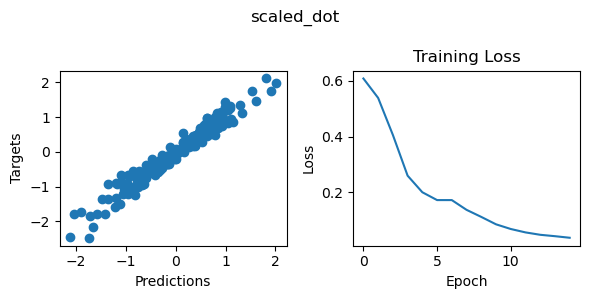

In [13]:
multi_default_args = {
    "sequence_length": 50,
    "num_samples": 1000,
    "k": 16,
    "print_every": 10
}
multi_args = {
    # Smaller batch → more gradient updates per epoch; each head sees more
    # diversity and specialises faster in 15 epochs.
    "batch_size": 32,
    "num_epochs": 15,
    # 3e-3 matches the single-head setting; gradient clipping keeps it stable.
    "lr": 3e-3,
    # 128 hidden units let all 3 heads represent their respective operations
    # (add / multiply / average) from the 4-D input.
    "hidden_dim": 128,
    # query_dim unused by ScaledDot, kept for interface compatibility.
    "query_dim": 64,
    "input_dim": 4,
    "output_dim": 1,
    # Clip gradients so the head_aggregator doesn't blow up early in training.
    "gradient_clip_val": 1.0,
    # One head per target operation.
    "num_heads": 3
}
if __name__ == "__main__":
    set_seed()
    device = "cuda:0" if torch.cuda.is_available() else "cpu"

    # Configuration
    attention_type = "scaled_dot"

    # Create dataset
    data = MultiDimSequenceData(
        num_samples=multi_default_args["num_samples"],
        max_seq_len=multi_default_args["sequence_length"],
        k=multi_default_args["k"],
        variable_len=True
    )

    # Create model with specified attention type
    model = MultiHeadAttentionNetwork(
        input_dim=multi_args["input_dim"],
        hidden_dim=multi_args["hidden_dim"],
        query_dim=multi_args["query_dim"],
        output_dim=multi_args["output_dim"],
        num_heads=multi_args["num_heads"],
        attention_type=attention_type
    )
    optimizer = torch.optim.Adam(model.parameters(), lr=multi_args["lr"])

    # Create trainer
    trainer = Trainer(
        batch_size=multi_args["batch_size"],
        max_epochs=multi_args["num_epochs"],
        gradient_clip_val=multi_args["gradient_clip_val"],
        device=device
    )

    trainer.fit(model, data, optimizer)

    tr, val = trainer.get_dataloader(data)
    preds, targets, avg_loss = trainer.predict(model, val)
    fig, axs = plt.subplots(1, 2, figsize=(6, 3))
    fig.suptitle(attention_type)
    axs[0].scatter(preds, targets)
    axs[0].set_xlabel("Predictions")
    axs[0].set_ylabel("Targets")
    axs[1].plot(trainer.train_loss)
    axs[1].set_ylabel("Loss")
    axs[1].set_xlabel("Epoch")
    axs[1].set_title("Training Loss")
    fig.tight_layout()
